In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
nav = pd.read_csv("../data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    latest_date = temp["date"].max()

    latest_nav = temp.iloc[-1]["nav"]

    row = {
        "amfi_code": fund
    }

    for years in [1,3,5]:

        target_date = (
            latest_date
            - pd.DateOffset(years=years)
        )

        historical = temp[
            temp["date"] <= target_date
        ]

        if len(historical) > 0:

            start_nav = historical.iloc[-1]["nav"]

            cagr = (
                (latest_nav/start_nav)
                ** (1/years)
                - 1
            )

            row[f"cagr_{years}yr"] = cagr

        else:

            row[f"cagr_{years}yr"] = np.nan

    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,NaN
1,100025,0.037050,0.039164,NaN
2,100033,0.532324,0.324425,NaN
3,101206,0.479241,0.289677,NaN
4,101207,-0.239860,-0.041524,NaN


In [4]:
rf = 0.065

sharpe_data = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    annual_return = (
        returns.mean() * 252
    )

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_volatility

    sharpe_data.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [5]:
sortino_data = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean() * 252
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_data.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [6]:
benchmark = pd.read_csv(
    "../data/processed/clean_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    slope, intercept, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252

    beta = slope

    alpha_beta.append(
        [fund, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [7]:
dd_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    running_max = (
        temp["nav"].cummax()
    )

    drawdown = (
        temp["nav"]
        / running_max
        - 1
    )

    max_dd = drawdown.min()

    dd_results.append(
        [fund,max_dd]
    )

dd_df = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [9]:
import pandas as pd
perf=pd.read_csv("../data/processed/clean_performance.csv")
perf.head()
scorecard = (
    cagr_df
    .merge(sharpe_df,on="amfi_code")
    .merge(alpha_beta_df,on="amfi_code")
    .merge(dd_df,on="amfi_code")
    .merge(
        perf[
            [
                "amfi_code",
                "expense_ratio_pct",
                "scheme_name"
            ]
        ],
        on="amfi_code"
    )
)

In [10]:
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        pct=True,
        ascending=False
    )
)

In [11]:
scorecard["score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["dd_rank"] * 10

)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

scorecard.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,scheme_name,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,score
25,120505,0.296047,0.317775,NaN,1.180101,0.292636,0.000549,-0.181885,1.36,ICICI Pru Midcap Fund - Regular - Growth,0.900,0.900,0.950,0.6500,0.625,84.5000
16,119094,0.222611,0.351118,NaN,0.998231,0.260767,-0.066265,-0.209609,1.38,Axis Midcap Fund - Regular - Growth,1.000,0.750,0.800,0.6000,0.700,80.7500
2,100033,0.532324,0.324425,NaN,1.093699,0.271954,0.005104,-0.162172,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.925,0.850,0.875,0.6000,0.500,80.5000
34,148567,0.203607,0.340009,NaN,1.448291,0.269838,0.023684,-0.112657,1.46,Mirae Asset Large Cap Fund - Regular - Growth,0.975,1.000,0.850,0.4500,0.200,80.0000
30,120843,0.266571,0.295828,NaN,1.306744,0.273305,-0.022830,-0.129740,1.45,Kotak Flexicap Fund - Regular - Growth,0.850,0.975,0.900,0.4750,0.325,78.2500
24,120504,0.130643,0.324874,NaN,1.026524,0.211948,0.016232,-0.125883,0.80,ICICI Pru Bluechip Fund - Direct - Growth,0.950,0.775,0.700,0.7250,0.300,75.7500
21,119598,0.827761,0.266699,NaN,0.945308,0.303370,-0.023196,-0.287060,1.43,SBI Small Cap Fund - Regular Plan - Growth,0.725,0.675,1.000,0.5000,0.900,75.1250
39,149324,0.651387,0.270004,NaN,0.949796,0.300579,0.011455,-0.311719,1.52,DSP Small Cap Fund - Regular - Growth,0.775,0.700,0.975,0.3625,0.925,74.9375
36,148569,0.397518,0.291789,NaN,1.234930,0.282704,0.018134,-0.163967,1.60,Mirae Asset Tax Saver Fund - Regular - Growth,0.825,0.950,0.925,0.1125,0.525,73.9375
19,119551,0.604373,0.304565,NaN,1.208267,0.232010,-0.031751,-0.150124,1.54,SBI Bluechip Fund - Regular Plan - Growth,0.875,0.925,0.775,0.2625,0.425,73.0625


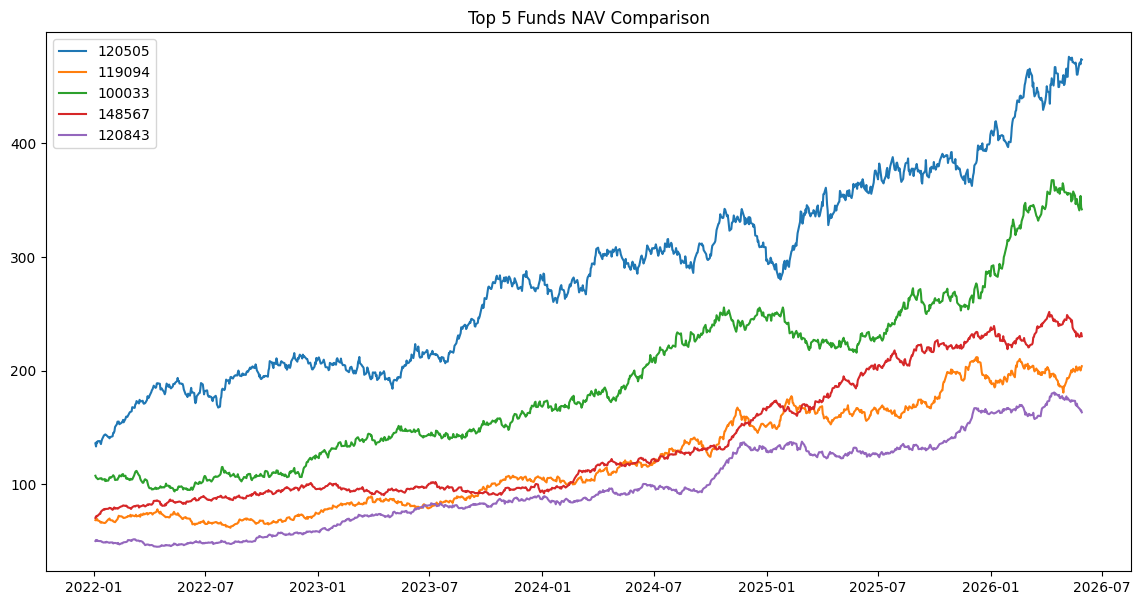

In [12]:
top5 = scorecard.head(5)

top_funds = top5["amfi_code"].tolist()

plt.figure(figsize=(14,7))

for fund in top_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.show()